In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix, roc_curve
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [ ]:
# Change this path if necessary
FILE_PATH = "DataSets_Codes\Loan_default.csv"

df = pd.read_csv(FILE_PATH)

print("Dataset shape:", df.shape)
display(df.head())
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (148670, 34)


,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0



Columns:
['ID', 'year', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type', 'loan_purpose', 'Credit_Worthiness', 'open_credit', 'business_or_commercial', 'loan_amount', 'rate_of_interest', 'Interest_rate_spread', 'Upfront_charges', 'term', 'Neg_ammortization', 'interest_only', 'lump_sum_payment', 'property_value', 'construction_type', 'occupancy_type', 'Secured_by', 'total_units', 'income', 'credit_type', 'Credit_Score', 'co-applicant_credit_type', 'age', 'submission_of_application', 'LTV', 'Region', 'Security_Type', 'Status', 'dtir1']


### Fix column names

In [13]:
df = df.rename(columns={
    'Gender': 'gender',
    'Credit_Worthiness': 'credit_worthiness',
    'Interest_rate_spread': 'interest_rate_spread',
    'Upfront_charges': 'upfront_charges',
    'term': 'loan_term_months',
    'Neg_ammortization': 'negative_amortization',
    'Secured_by': 'secured_by',
    'Credit_Score': 'credit_score',
    'Region': 'region',
    'Security_Type': 'security_type',
    'Status': 'status',
    'dtir1': 'debt_to_income_ratio'
})

# Clean any remaining column names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace("-", "_", regex=False)
)

print(df.columns.tolist())

['id', 'year', 'loan_limit', 'gender', 'approv_in_adv', 'loan_type', 'loan_purpose', 'credit_worthiness', 'open_credit', 'business_or_commercial', 'loan_amount', 'rate_of_interest', 'interest_rate_spread', 'upfront_charges', 'loan_term_months', 'negative_amortization', 'interest_only', 'lump_sum_payment', 'property_value', 'construction_type', 'occupancy_type', 'secured_by', 'total_units', 'income', 'credit_type', 'credit_score', 'co_applicant_credit_type', 'age', 'submission_of_application', 'ltv', 'region', 'security_type', 'status', 'debt_to_income_ratio']


### Basic data checks

In [14]:
print(df.info())

print("\nMissing values:")
display(df.isnull().sum().sort_values(ascending=False).head(20))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nTarget distribution:")
print(df['status'].value_counts(dropna=False))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   id                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  object 
 3   gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   credit_worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  interest_rate_spread       112031 non-null  float64
 13  upfront_charges            10

upfront_charges              39642
interest_rate_spread         36639
rate_of_interest             36439
debt_to_income_ratio         24121
property_value               15098
ltv                          15098
income                        9150
loan_limit                    3344
approv_in_adv                  908
age                            200
submission_of_application      200
loan_purpose                   134
negative_amortization          121
loan_term_months                41
year                             0
id                               0
business_or_commercial           0
open_credit                      0
lump_sum_payment                 0
interest_only                    0
dtype: int64


Duplicate rows: 0

Target distribution:
status
0    112031
1     36639
Name: count, dtype: int64


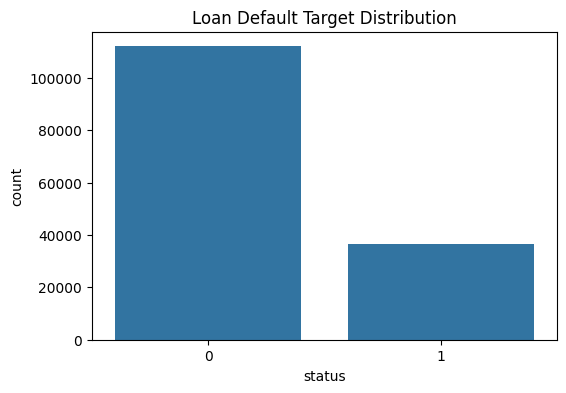

In [15]:
df = df.drop_duplicates().reset_index(drop=True)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='status')
plt.title('Loan Default Target Distribution')
plt.show()

## Numerical EDA

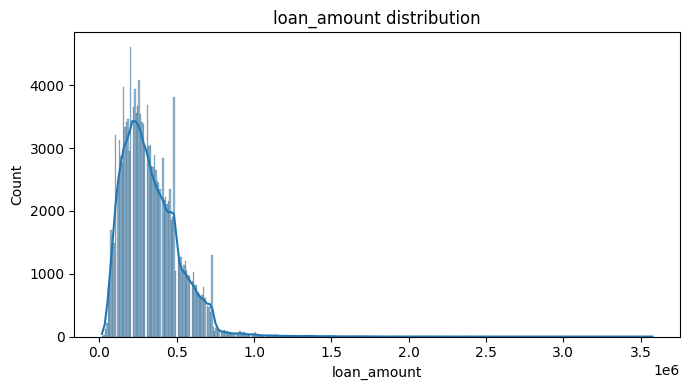

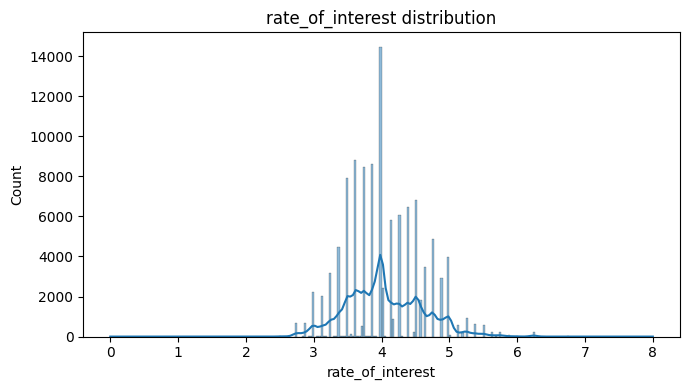

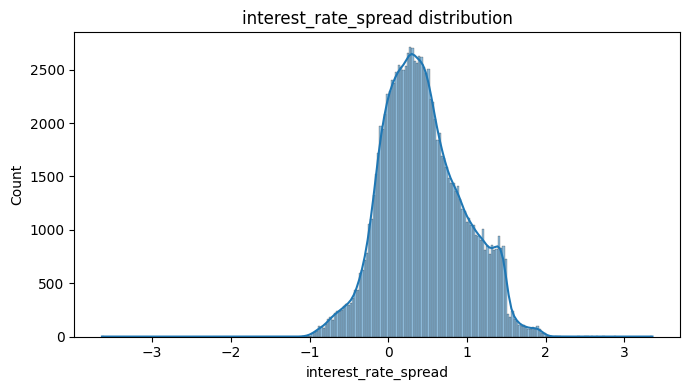

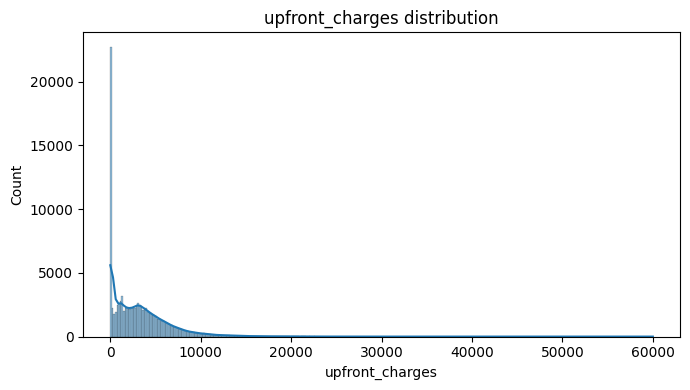

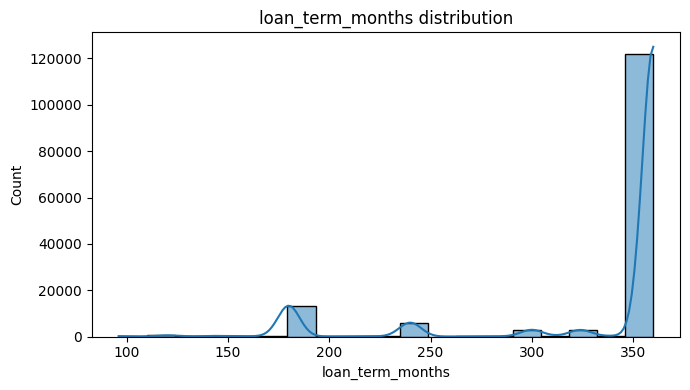

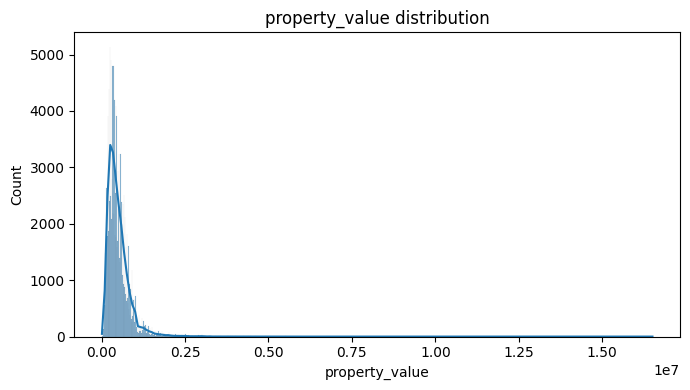

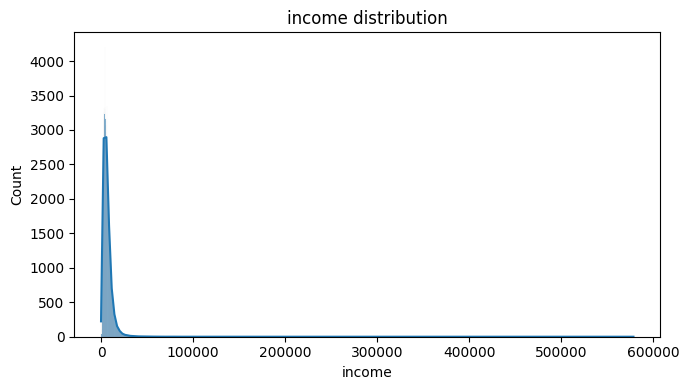

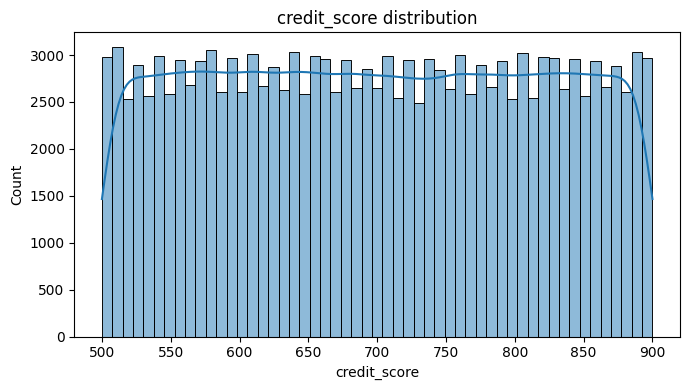

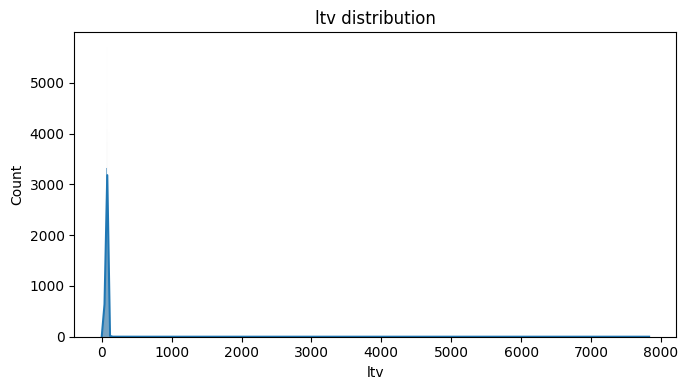

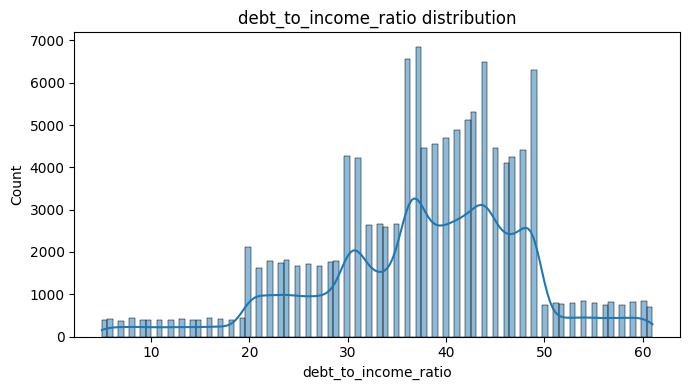

In [16]:
nums = [
    'loan_amount', 'rate_of_interest', 'interest_rate_spread',
    'upfront_charges', 'loan_term_months', 'property_value',
    'income', 'credit_score', 'ltv', 'debt_to_income_ratio'
]

nums = [c for c in nums if c in df.columns]

for n in nums:
    plt.figure(figsize=(7, 4))
    sns.histplot(data=df, x=n, kde=True)
    plt.title(f"{n} distribution")
    plt.tight_layout()
    plt.show()

## Categorical EDA

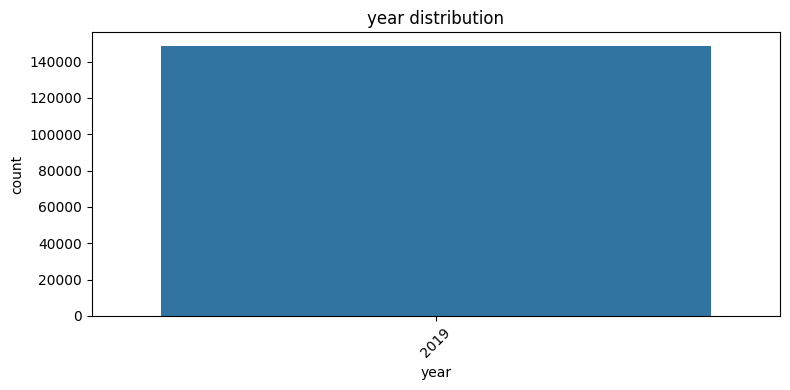

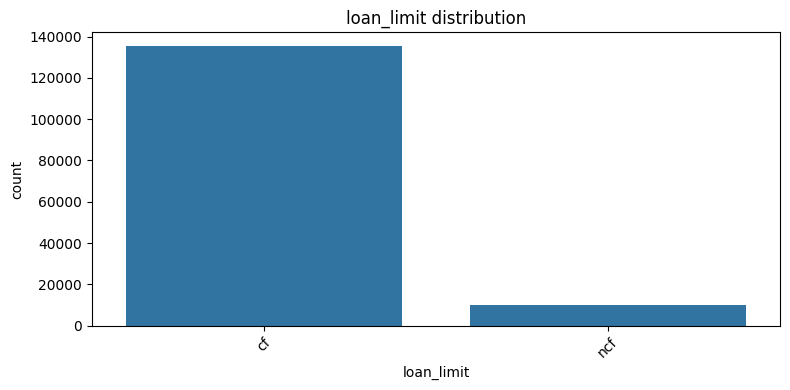

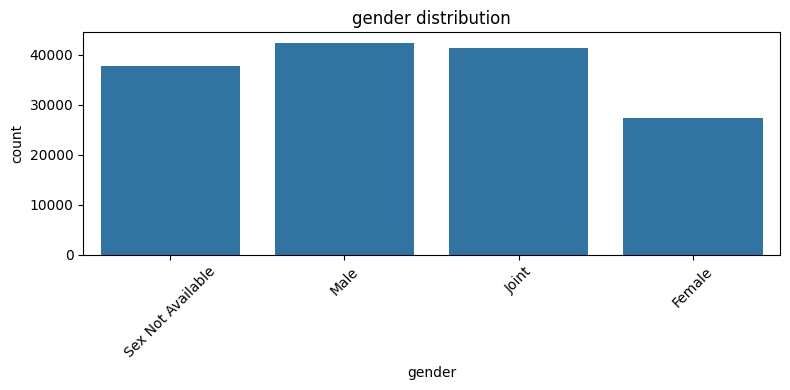

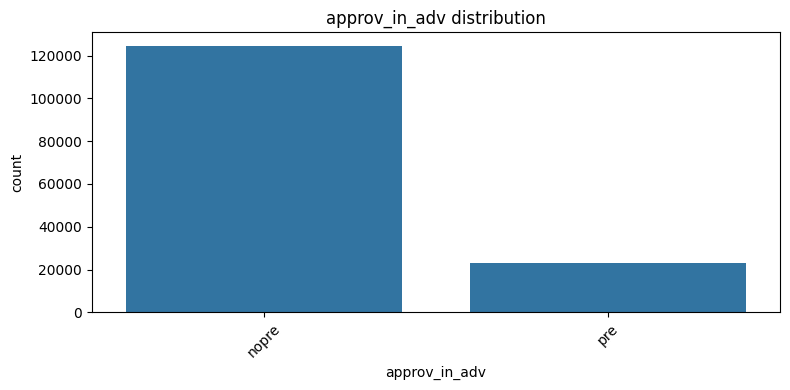

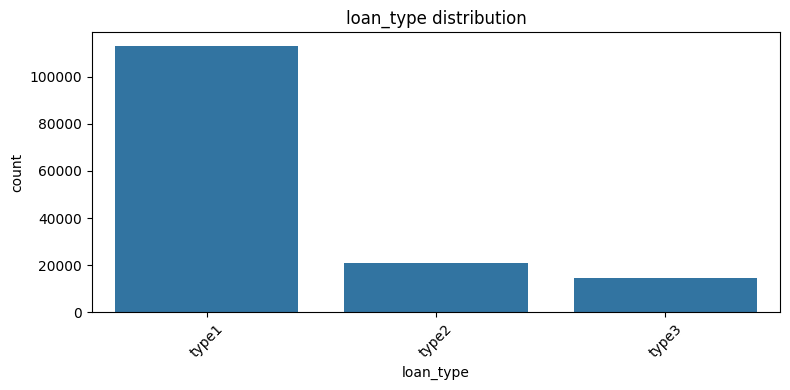

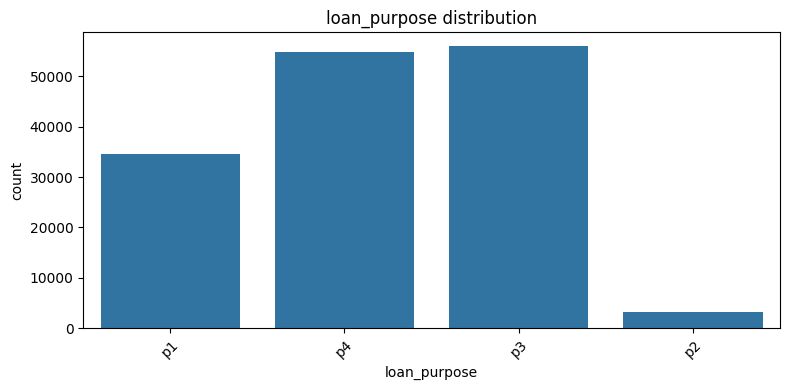

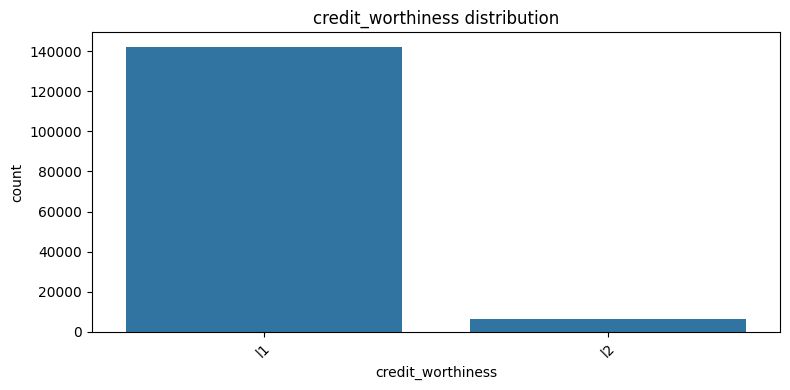

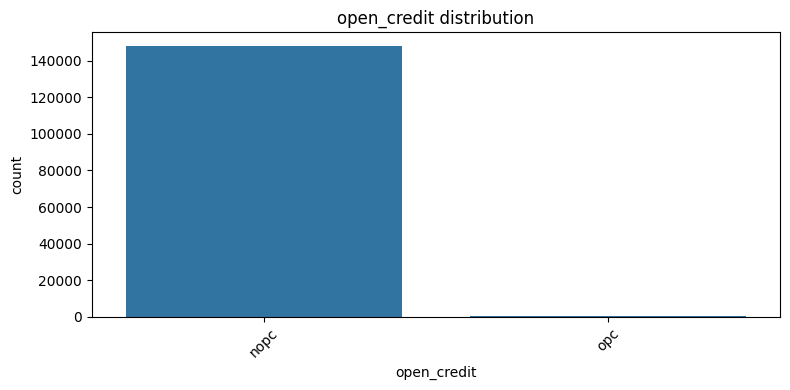

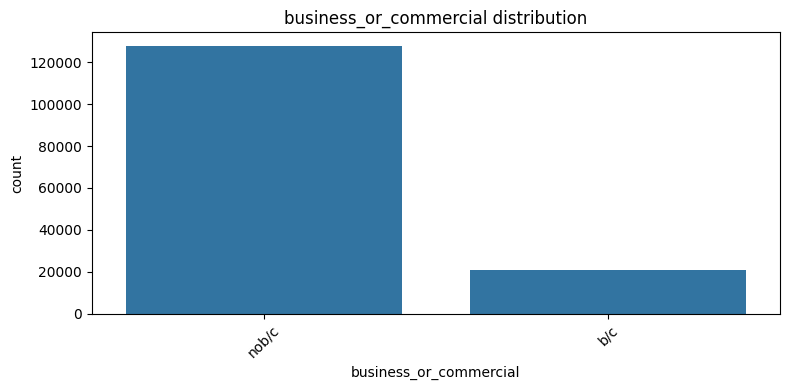

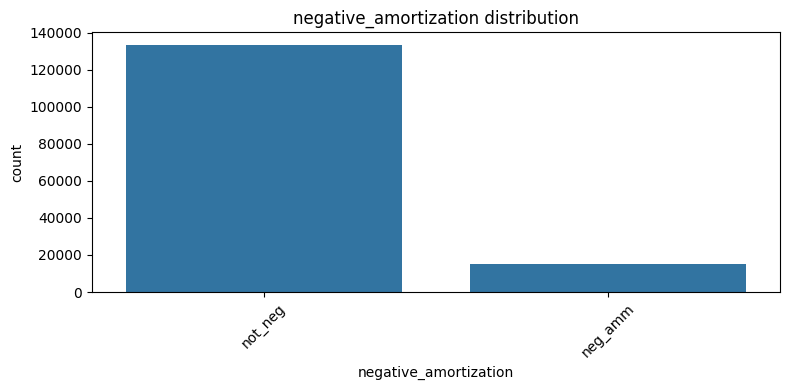

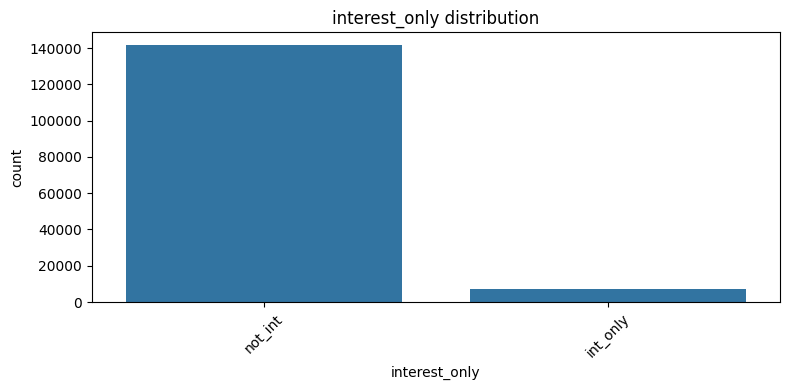

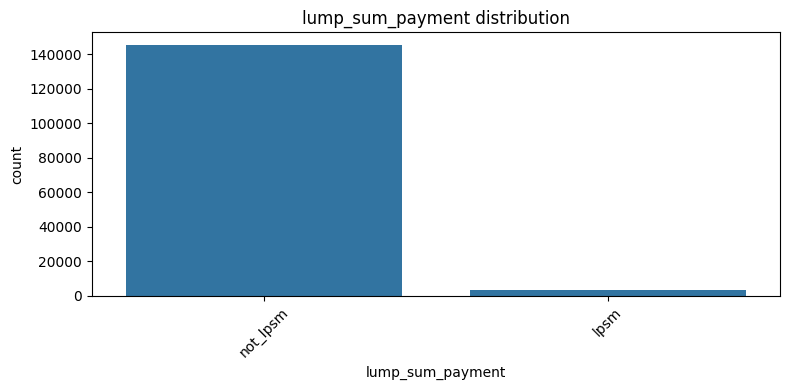

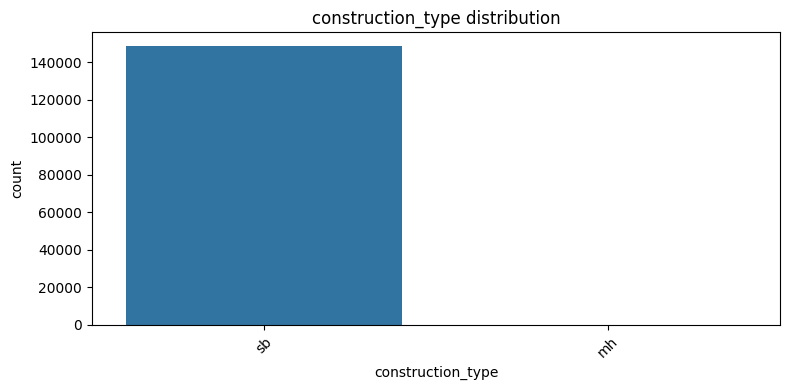

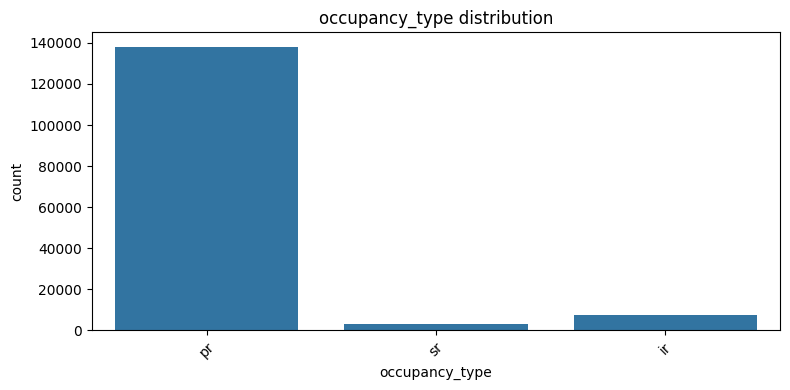

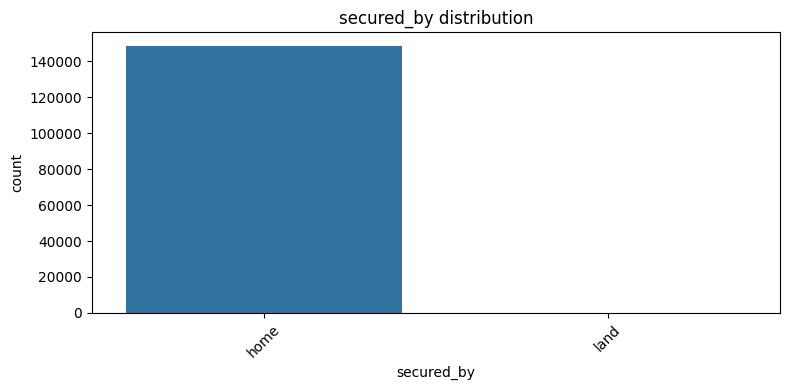

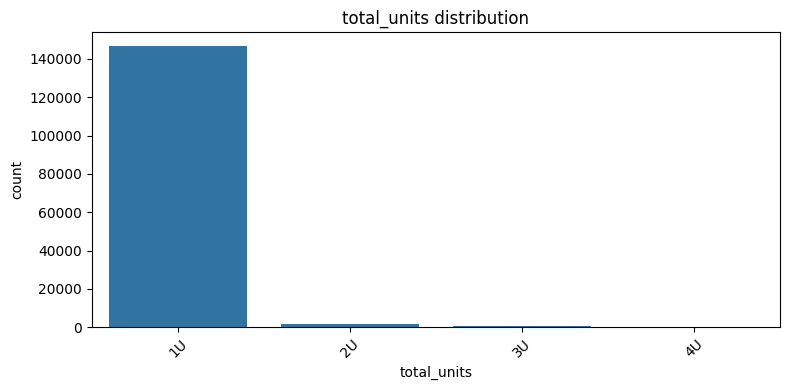

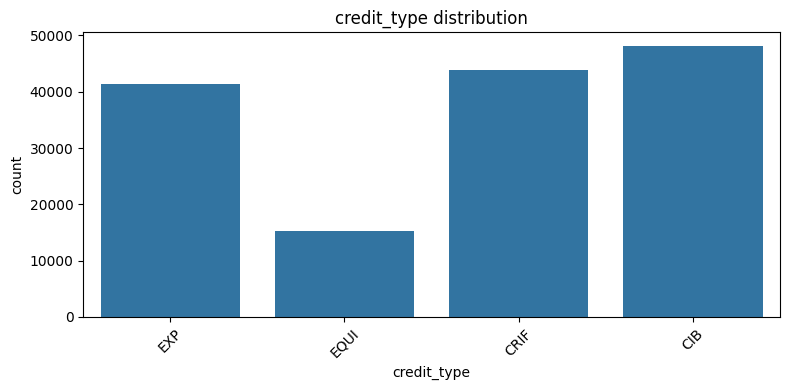

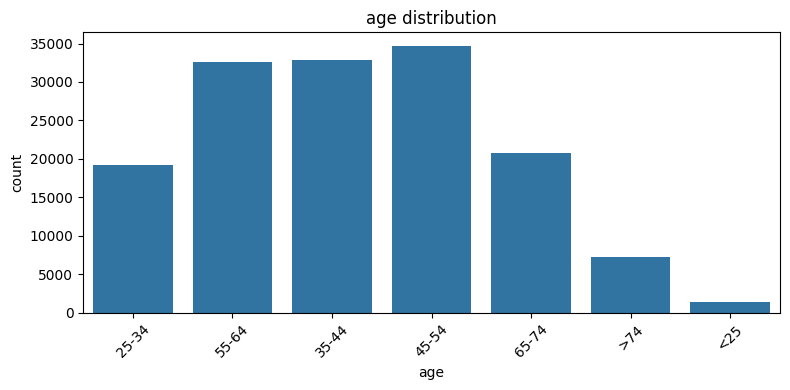

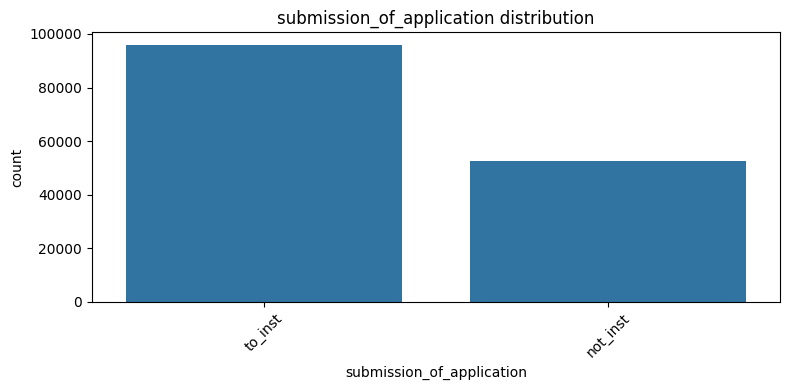

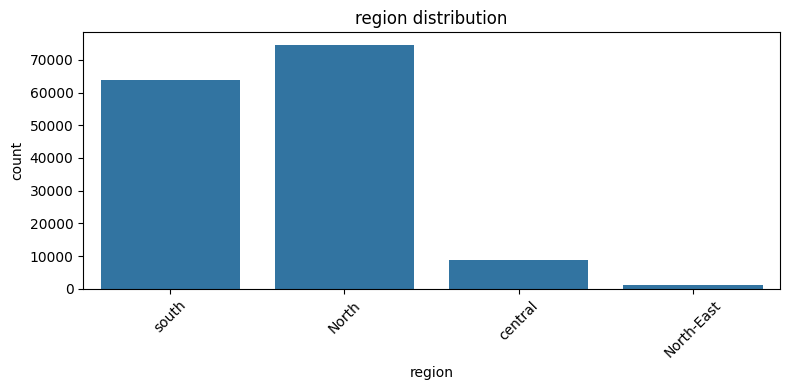

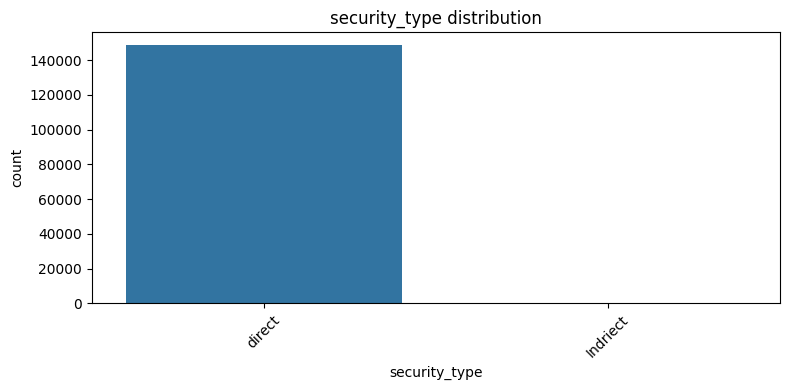

In [17]:
cats = [
    'year', 'loan_limit', 'gender', 'approv_in_adv', 'loan_type',
    'loan_purpose', 'credit_worthiness', 'open_credit',
    'business_or_commercial', 'negative_amortization',
    'interest_only', 'lump_sum_payment', 'construction_type',
    'occupancy_type', 'secured_by', 'total_units', 'credit_type',
    'co-applicant_credit_type', 'age', 'submission_of_application',
    'region', 'security_type', 'credit_risk', 'high_loan'
]

cats = [c for c in cats if c in df.columns]

for n in cats:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=n)
    plt.title(f"{n} distribution")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## Numerical features vs target

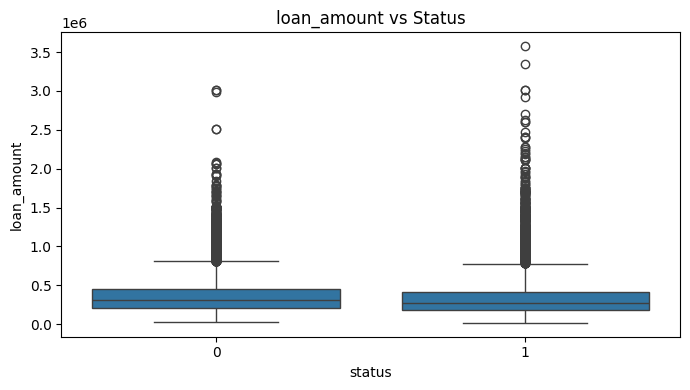

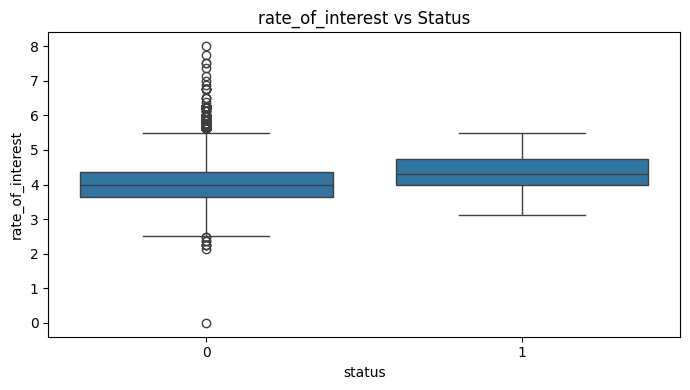

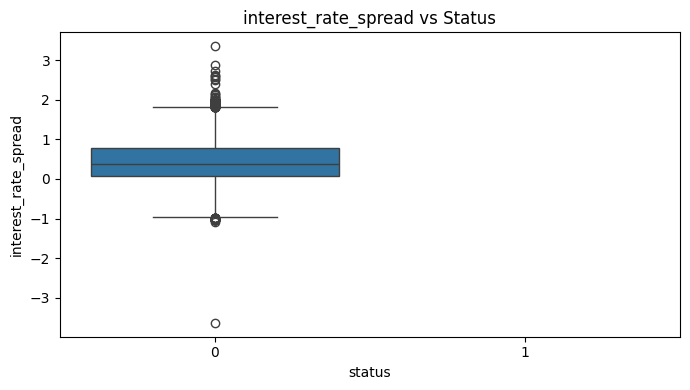

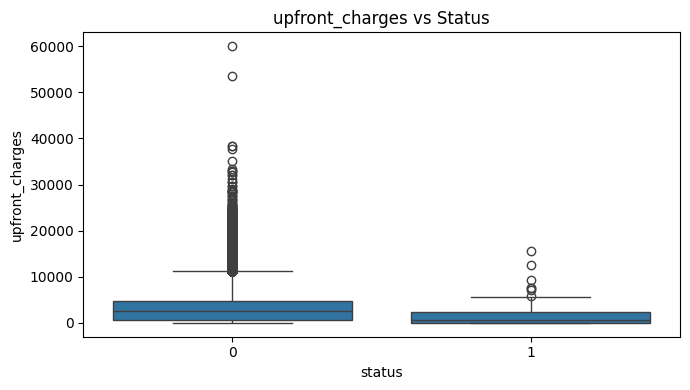

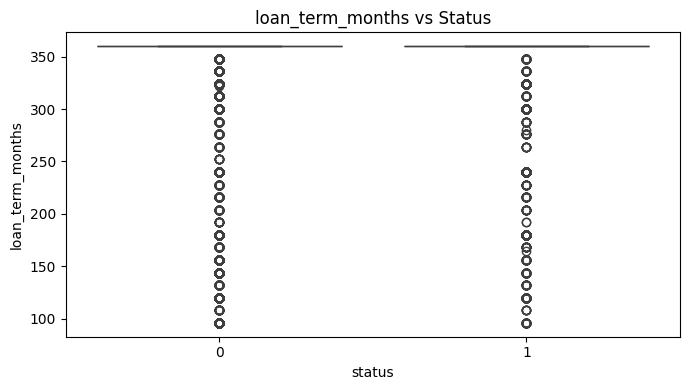

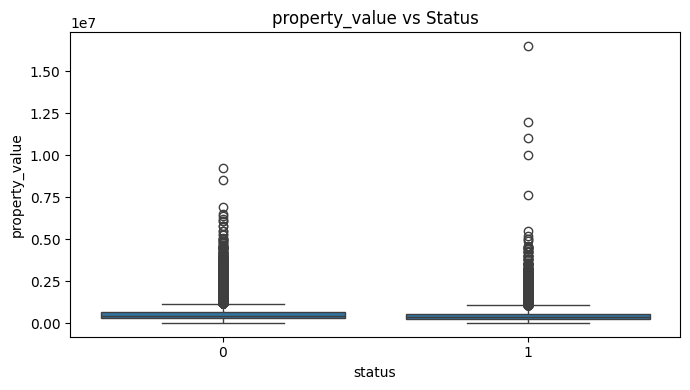

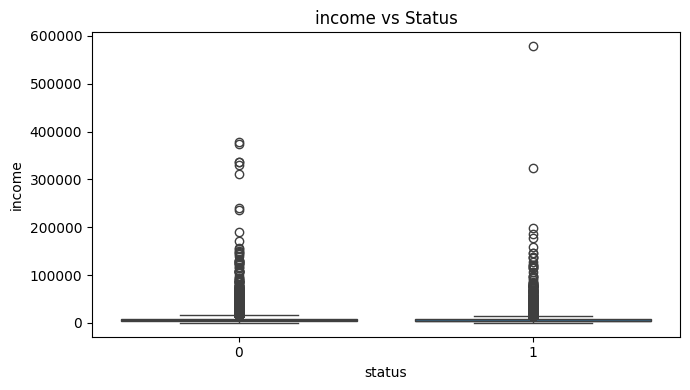

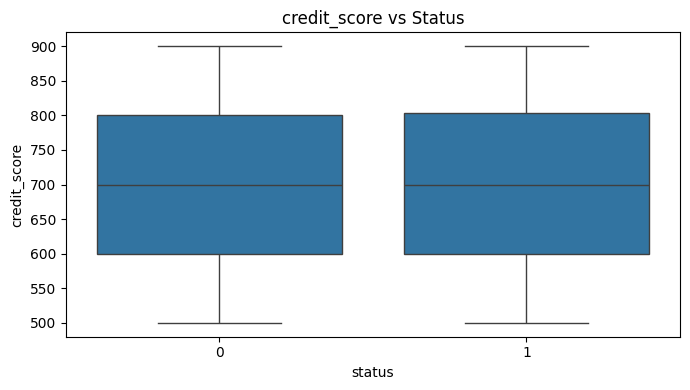

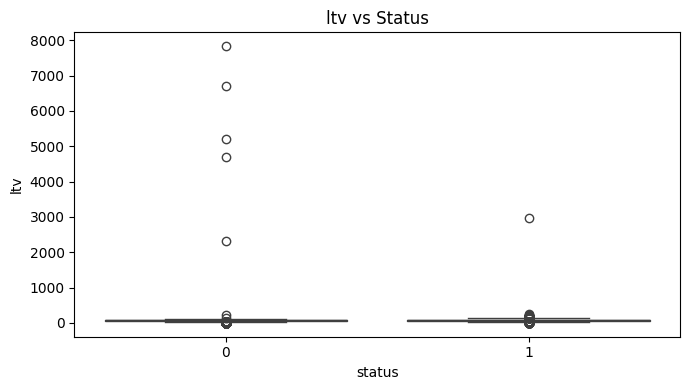

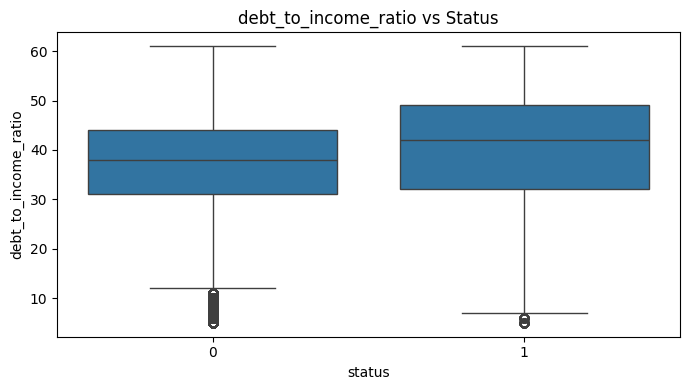

In [18]:
# Boxplots are appropriate for continuous numerical variables
for n in nums:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=df, x='status', y=n)
    plt.title(f"{n} vs Status")
    plt.tight_layout()
    plt.show()

## Prepare X and y

In [19]:
if 'status' not in df.columns:
    raise ValueError("Column 'status' was not found.")

# Convert common binary target formats to 0/1
if pd.api.types.is_numeric_dtype(df['status']):
    values = sorted(df['status'].dropna().unique())
    if set(values).issubset({0, 1}):
        y = df['status'].astype(int)
    elif len(values) == 2:
        mapping = {values[0]: 0, values[1]: 1}
        y = df['status'].map(mapping).astype(int)
    else:
        raise ValueError(f"Status is not binary: {values}")
else:
    s = df['status'].astype(str).str.strip().str.lower()
    mapping = {
        'no': 0, 'n': 0, '0': 0, 'false': 0, 'non-default': 0,
        'yes': 1, 'y': 1, '1': 1, 'true': 1, 'default': 1
    }
    y = s.map(mapping)

    if y.isna().any():
        values = s.dropna().unique().tolist()
        if len(values) != 2:
            raise ValueError(f"Status is not binary: {values}")
        auto_mapping = {values[0]: 0, values[1]: 1}
        y = s.map(auto_mapping)

    y = y.astype(int)

X = df.drop(columns=['status'])

print("X:", X.shape)
print("y:", y.shape)
print("\nTarget:")
print(y.value_counts())

X: (148670, 33)
y: (148670,)

Target:
status
0    112031
1     36639
Name: count, dtype: int64


## Train/Test Split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (118936, 33)
X_test : (29734, 33)
y_train: (118936,)
y_test : (29734,)


## Identify numerical and categorical features

In [21]:
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical columns:")
print(num_cols)

print("\nCategorical columns:")
print(cat_cols)

Numerical columns:
['id', 'year', 'loan_amount', 'rate_of_interest', 'interest_rate_spread', 'upfront_charges', 'loan_term_months', 'property_value', 'income', 'credit_score', 'ltv', 'debt_to_income_ratio']

Categorical columns:
['loan_limit', 'gender', 'approv_in_adv', 'loan_type', 'loan_purpose', 'credit_worthiness', 'open_credit', 'business_or_commercial', 'negative_amortization', 'interest_only', 'lump_sum_payment', 'construction_type', 'occupancy_type', 'secured_by', 'total_units', 'credit_type', 'co_applicant_credit_type', 'age', 'submission_of_application', 'region', 'security_type']


## Preprocessing

**Numerical:** median imputation → StandardScaler

**Categorical:** most-frequent imputation → OneHotEncoder

The test set is transformed using the already-fitted training preprocessor.

In [22]:
num_trans = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('scr', StandardScaler())
])

cat_trans = Pipeline([
    ('imp', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer([
    ('num_pre', num_trans, num_cols),
    ('cat_pre', cat_trans, cat_cols)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("X_train processed:", X_train_processed.shape)
print("X_test processed :", X_test_processed.shape)

X_train processed: (118936, 71)
X_test processed : (29734, 71)


## VarianceThreshold Feature Selection

In [23]:
selector = VarianceThreshold(threshold=0.01)

X_train_sele = selector.fit_transform(X_train_processed)
X_test_sele = selector.transform(X_test_processed)

print("Before feature selection:", X_train_processed.shape)
print("After feature selection :", X_train_sele.shape)

Before feature selection: (118936, 71)
After feature selection : (118936, 57)


## ANN Model

Architecture:

**Input → Dense(128, ReLU) → BatchNorm → Dropout → Dense(64, ReLU) → BatchNorm → Dropout → Dense(32, ReLU) → Dropout → Dense(1, Sigmoid)**

For binary Loan Default classification:
- **ReLU** is used in hidden layers.
- **Sigmoid** is used in the output layer.
- **Binary Cross-Entropy** is used as loss.
- **Adam** is used as optimizer.
- Backpropagation calculates gradients during training.
- Batch Normalization stabilizes training.
- Dropout helps reduce overfitting.

In [24]:
input_dim = X_train_sele.shape[1]

model = Sequential([
    Dense(128, activation='relu', input_shape=(input_dim,)),
    BatchNormalization(),
    Dropout(0.30),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.20),

    Dense(32, activation='relu'),
    Dropout(0.10),

    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

model.summary()

d:\Problem_Solving_Practice\Deep_Learning\.venv-1\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         7,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,561 (72.50 KB)

 Trainable params: 18,177 (71.00 KB)

 Non-trainable params: 384 (1.50 KB)

## Train ANN

Each epoch performs forward propagation → loss calculation → backpropagation → Adam weight update.

In [25]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_auc',
        mode='max',
        patience=8,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6
    )
]

history = model.fit(
    X_train_sele,
    y_train,
    validation_split=0.20,
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
2974/2974 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9454 - auc: 0.9866 - loss: 0.1267 - precision: 0.8979 - recall: 0.8786 - val_accuracy: 0.9861 - val_auc: 0.9988 - val_loss: 0.0382 - val_precision: 0.9469 - val_recall: 0.9997 - learning_rate: 0.0010
Epoch 2/100
2974/2974 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9830 - auc: 0.9977 - loss: 0.0471 - precision: 0.9565 - recall: 0.9755 - val_accuracy: 0.9898 - val_auc: 0.9993 - val_loss: 0.0290 - val_precision: 0.9606 - val_recall: 0.9995 - learning_rate: 0.0010
Epoch 3/100
2974/2974 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9876 - auc: 0.9983 - loss: 0.0364 - precision: 0.9670 - recall: 0.9832 - val_accuracy: 0.9911 - val_auc: 0.9994 - val_loss: 0.0312 - val_precision: 0.9652 - val_recall: 0.9998 - learning_rate: 0.0010
Epoch 4/100
2974/2974 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9904 - auc: 0.9988 - loss: 0.0291 - precision: 0.9739 - recall: 0.9877 - val_accuracy: 0.9931 - val_auc: 0.9994 - val_loss: 

## Training Curves

Metrics available:
['accuracy', 'auc', 'loss', 'precision', 'recall', 'val_accuracy', 'val_auc', 'val_loss', 'val_precision', 'val_recall', 'learning_rate']


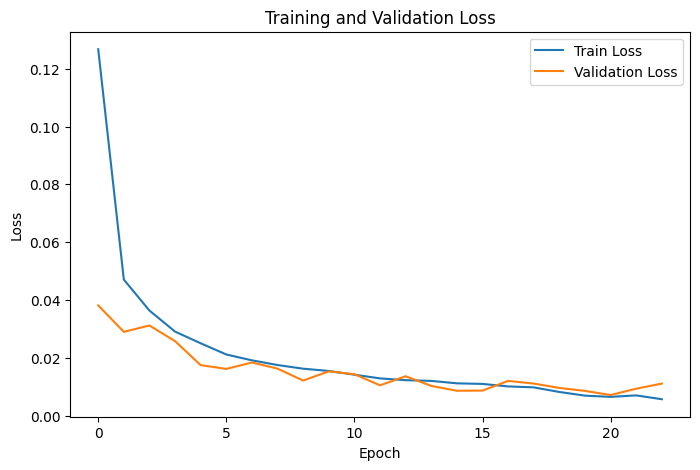

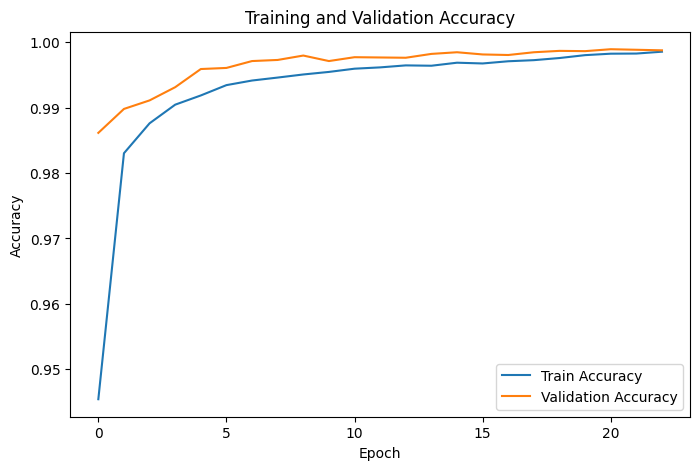

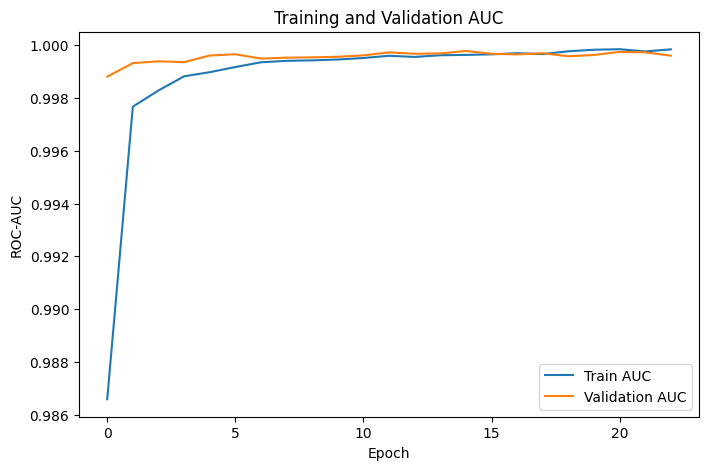

In [26]:
history_df = pd.DataFrame(history.history)

print("Metrics available:")
print(history_df.columns.tolist())

plt.figure(figsize=(8, 5))
plt.plot(history_df['loss'], label='Train Loss')
plt.plot(history_df['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df['accuracy'], label='Train Accuracy')
plt.plot(history_df['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df['auc'], label='Train AUC')
plt.plot(history_df['val_auc'], label='Validation AUC')
plt.xlabel('Epoch')
plt.ylabel('ROC-AUC')
plt.title('Training and Validation AUC')
plt.legend()
plt.show()

## Test Set Evaluation

In [27]:
test_loss, test_accuracy, test_precision, test_recall, test_auc = model.evaluate(
    X_test_sele,
    y_test,
    verbose=0
)

print(f"Test Loss      : {test_loss:.4f}")
print(f"Test Accuracy  : {test_accuracy:.4f}")
print(f"Test Precision : {test_precision:.4f}")
print(f"Test Recall    : {test_recall:.4f}")
print(f"Test ROC-AUC   : {test_auc:.4f}")

Test Loss      : 0.0073
Test Accuracy  : 0.9980
Test Precision : 0.9923
Test Recall    : 0.9997
Test ROC-AUC   : 0.9998


In [29]:
# Predictions
y_prob = model.predict(X_test_sele, verbose=0).ravel()
y_pred = (y_prob >= 0.50).astype(int)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_prob)

evaluation = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC'],
    'Score': [accuracy, precision, recall, f1, roc_auc]
})

display(evaluation.style.format({'Score': '{:.4f}'}))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=['Non-Default', 'Default'],
    digits=4,
    zero_division=0
))

,Metric,Score
0,Accuracy,0.9980
1,Precision,0.9923
2,Recall,0.9997
3,F1 Score,0.9960
4,ROC-AUC,0.9999



Classification Report:
              precision    recall  f1-score   support

 Non-Default     0.9999    0.9975    0.9987     22406
     Default     0.9923    0.9997    0.9960      7328

    accuracy                         0.9980     29734
   macro avg     0.9961    0.9986    0.9973     29734
weighted avg     0.9980    0.9980    0.9980     29734



## Confusion Matrix

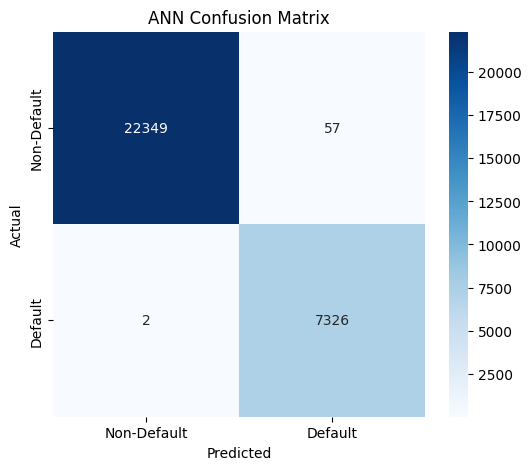

In [30]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Non-Default', 'Default'],
    yticklabels=['Non-Default', 'Default']
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('ANN Confusion Matrix')
plt.show()

## ROC Curve

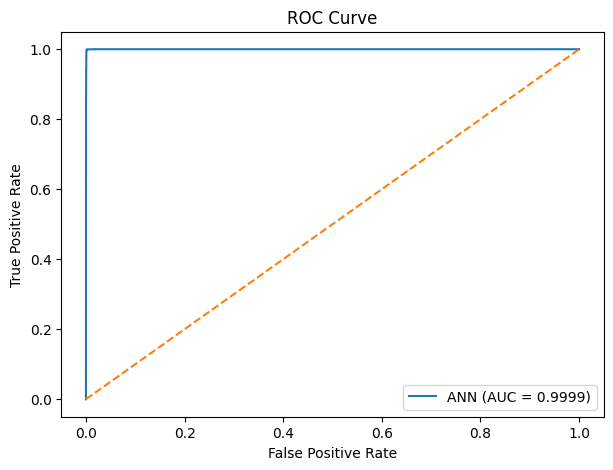

In [31]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'ANN (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

## Predict a New Loan

In [ ]:
# Demonstration: use one test record as a new loan
new_loan = X_test.iloc[[0]].copy()

new_processed = preprocessor.transform(new_loan)
new_selected = selector.transform(new_processed)

probability = float(model.predict(new_selected, verbose=0)[0][0])
prediction = int(probability >= 0.50)

print(f"Default probability: {probability:.4f}")
print(f"Predicted class: {prediction}")
print("Prediction:", "Default" if prediction == 1 else "Non-Default")

Default probability: 0.0000
Predicted class: 0
Prediction: Non-Default


: 

## Final Workflow

**Loan Default Dataset**
↓  
**Data Cleaning**
↓  
**EDA**
↓  
**X / y Separation**
↓  
**Train-Test Split**
↓  
**Imputation + One-Hot Encoding + Scaling**
↓  
**VarianceThreshold Feature Selection**
↓  
**ANN**
↓  
**ReLU Hidden Layers**
↓  
**Batch Normalization + Dropout**
↓  
**Sigmoid Output**
↓  
**Binary Cross-Entropy**
↓  
**Backpropagation**
↓  
**Adam Optimizer**
↓  
**Prediction**
↓  
**Accuracy + Precision + Recall + F1 + ROC-AUC + Confusion Matrix + ROC Curve**

In [ ]:
# Optional: save the trained model
# model.save("loan_default_ann.keras")